# spOT-NMF — Proximity (Niche) Network Tutorial

Once spOT-NMF has deconvolved a section into **gene programs**, a natural next
question is *how those programs are arranged relative to one another in space*.
spOT-NMF answers this with **proximity networks** (a.k.a. *niche* or
*program–program interaction* networks), implemented in
[`spotnmf.niche_networks`](../../../spotnmf/niche_networks.py).

The idea is simple:

* A program is **present** at a spot if its usage there is high (top decile).
* Two programs are **proximal** if they tend to be present *at the same spots* —
  i.e. they co-occur across the tissue.
* Each ordered pair of programs `(A → B)` gets a directed edge whose weight is the
  (smoothed) probability that **B** is present *given* **A** is present.
* [Infomap](https://www.mapequation.org/) community detection then groups the
  programs into **niches** — sets of programs that consistently share the same
  neighbourhoods.

This notebook builds such a network step by step on the small example dataset that
ships with the repo, renders it inline, and finishes with the single-call
`plot_network_analysis` API (and its `spotnmf network` CLI equivalent) that writes
publication-ready PDFs to disk.

> Runs on CPU or GPU; the only slow part is the deconvolution used to produce the
> program usages (a couple of minutes). The network analysis itself is instant.

## 0. Setup

In [1]:
import os
os.environ["TQDM_DISABLE"] = "1"   # keep the deconvolution progress bar out of the notebook

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spotnmf as spot
from spotnmf import niche_networks as nn

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"

print(f"spOT-NMF version: {spot.__version__}")

spOT-NMF version: 0.1.4


In [2]:
# Locate the example dataset that ships in the repo (data/test_data/...).
def find_example_dataset(filename="dataset10_adata_spatial.h5ad"):
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        candidate = base / "data" / "test_data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find data/test_data/{filename}. "
        "Run this notebook from within a clone of the spOT-NMF repository, "
        "or set DATA_PATH to your own .h5ad file."
    )

DATA_PATH = find_example_dataset()
SAMPLE_NAME = "Dataset10"
print(f"Using dataset: {DATA_PATH}")

Using dataset: Z:\postdoc\projects\spOT-NMF\data\test_data\dataset10_adata_spatial.h5ad


## 1. Program usages (the `W` matrix)

The proximity network is built entirely from the **per-spot usage matrix** `W`
(spots × programs) that deconvolution produces — the same
`topics_per_spot_*.csv` written by the CLI. Here we run a short deconvolution to
get one. If you have already run the [full pipeline](full_pipeline.ipynb), you can
instead load its `topics_per_spot_Dataset10.csv` and skip this cell.

In [3]:
adata = spot.io.read_adata(data_path=str(DATA_PATH), data_mode="h5ad")

# A short run (max_iter=30) is plenty to get usable usages for this demo.
results, losses = spot.models.run_spotnmf(
    adata, components=15,
    lr=0.001, h=0.01, w=0.01, eps=0.05, normalize_rows=True,
    max_iter=30,
)
W = results["topics_per_spot"]          # spots × programs (usage)
print(f"W (topics_per_spot): {W.shape}")
W.head()

Model Params: {'h': 0.01, 'w': 0.01, 'eps': 0.05, 'lr': 0.001, 'normalize_rows': True, 'cost': 'cosine', 'optim_name': 'adam', 'tol_inner': 1e-12, 'tol_outer': 1e-05, 'max_iter': 30, 'max_iter_inner': 1000, 'device': 'cuda'}


W (topics_per_spot): (189, 15)


,ot_1,ot_2,ot_3,ot_4,ot_5,ot_6,ot_7,ot_8,ot_9,ot_10,ot_11,ot_12,ot_13,ot_14,ot_15
0,0.022116,0.032889,0.015220,0.026230,0.225230,0.165571,0.052849,0.031549,0.007057,0.275370,0.053461,0.018076,0.014649,0.020996,0.038737
1,0.122520,0.044106,0.037028,0.065186,0.053230,0.109553,0.034832,0.018416,0.043181,0.205570,0.025995,0.113584,0.061214,0.024346,0.041239
2,0.166325,0.055801,0.036597,0.091940,0.034079,0.072102,0.029847,0.010927,0.003337,0.008671,0.033491,0.413264,0.027588,0.009993,0.006039
3,0.084901,0.016337,0.038554,0.088425,0.011032,0.130559,0.015876,0.010441,0.064733,0.005141,0.006705,0.416479,0.027049,0.044734,0.039034
4,0.026520,0.062235,0.040161,0.048850,0.174405,0.049788,0.087665,0.027483,0.074825,0.151389,0.032366,0.081008,0.072587,0.042164,0.028554


## 2. From usage to *presence*

A program contributes a little bit almost everywhere, so we first decide **where
each program is actually "on"**. Following `plot_network_analysis`, we keep only
the **top 10 % of spots** for each program (values below the 90th percentile are
zeroed). Everything downstream treats a program as *present* at a spot when its
(thresholded) usage exceeds `usage_threshold` — `0` after this step.

In [4]:
usage = W.copy()
for col in usage.columns:
    thresh = usage[col].quantile(0.90)
    usage.loc[usage[col] < thresh, col] = 0

USAGE_THRESHOLD = 0                       # "present" == usage > 0 after thresholding
present_per_program = (usage > USAGE_THRESHOLD).sum()
print(f"Spots: {usage.shape[0]}   Programs: {usage.shape[1]}")
print(f"Spots where each program is present (top decile): "
      f"{present_per_program.min()}–{present_per_program.max()}")

Spots: 189   Programs: 15
Spots where each program is present (top decile): 19–19


> **Why this matters for the thresholds below.** With only ~190 spots, each program
> is present at ~19 spots. The number of co-occurrence observations for an edge can
> therefore never exceed ~19 — so the CLI default `n_bins=1000` (designed for
> multi-sample Visium atlases with thousands of spots) would yield an **empty
> graph**. On small sections you must lower `n_bins` accordingly.

## 3. Pairwise co-occurrence statistics

`compute_pairwise_stats` counts, for every ordered pair `(A, B)`, how many of the
spots where **A** is present also have **B** present (`P2pos`) versus absent
(`P2neg`). We turn those counts into an edge weight with a smoothed conditional
probability

$$\text{val}(A\to B)=\frac{P2pos+1}{P2pos+P2neg+2}\in(0,1),$$

and keep only pairs whose weight exceeds `edge_threshold`.

In [5]:
EDGE_THRESHOLD = 0.2       # min |val| for an edge to be considered

stats = nn.compute_pairwise_stats(
    usage=usage, usage_threshold=USAGE_THRESHOLD, sample=SAMPLE_NAME,
)
# Smoothed conditional-presence probability (identical to plot_network_analysis).
stats[f"{SAMPLE_NAME}_val"] = (
    (stats[f"{SAMPLE_NAME}_P2pos"] + 1)
    / (stats[f"{SAMPLE_NAME}_P2pos"] + stats[f"{SAMPLE_NAME}_P2neg"] + 2)
)
stats = stats[stats[f"{SAMPLE_NAME}_val"].abs() > EDGE_THRESHOLD]
print(f"Candidate edges passing edge_threshold={EDGE_THRESHOLD}: {len(stats)}")
stats.head()

Candidate edges passing edge_threshold=0.2: 29


,group1,n,program_one,program_two,Dataset10_P2pos,Dataset10_P2neg,Dataset10_val
0,Dataset10,19,ot_1,ot_1,19,0,0.952381
5,Dataset10,19,ot_1,ot_6,6,13,0.333333
13,Dataset10,19,ot_1,ot_14,4,15,0.238095
16,Dataset10,19,ot_2,ot_2,19,0,0.952381
23,Dataset10,19,ot_2,ot_9,4,15,0.238095


## 4. Build the network graph

`build_network_graph` assembles a directed graph: one node per program (annotated
by `generate_node_attributes`) and one edge per surviving pair — provided that pair
was observed in at least `n_bins` spots. It returns both the full graph and a
`filtered` graph that drops programs left with no edges.

In [6]:
N_BINS = 5     # min. co-occurrence observations per edge (small because the section is small)

node_attrs = nn.generate_node_attributes(usage, USAGE_THRESHOLD, SAMPLE_NAME)
graph, graph_filtered = nn.build_network_graph(
    stats, node_attrs, sample=SAMPLE_NAME, n_bins=N_BINS,
)
print(f"Full graph:     {graph.number_of_nodes()} nodes, "
      f"{graph.number_of_edges()} edges")
print(f"Filtered graph: {graph_filtered.number_of_nodes()} nodes, "
      f"{graph_filtered.number_of_edges()} edges")

Full graph:     15 nodes, 14 edges
Filtered graph: 9 nodes, 14 edges


## 5. Detect niches and draw the network

`detect_communities_infomap` runs Infomap to label each program with a `cluster`
(its niche); `get_node_positions` computes a layout, and `base_plot` renders the
graph — nodes coloured by niche, directed edges coloured/weighted by co-occurrence
strength.

Infomap found 4 niche(s): [0, 1, 2, 3]


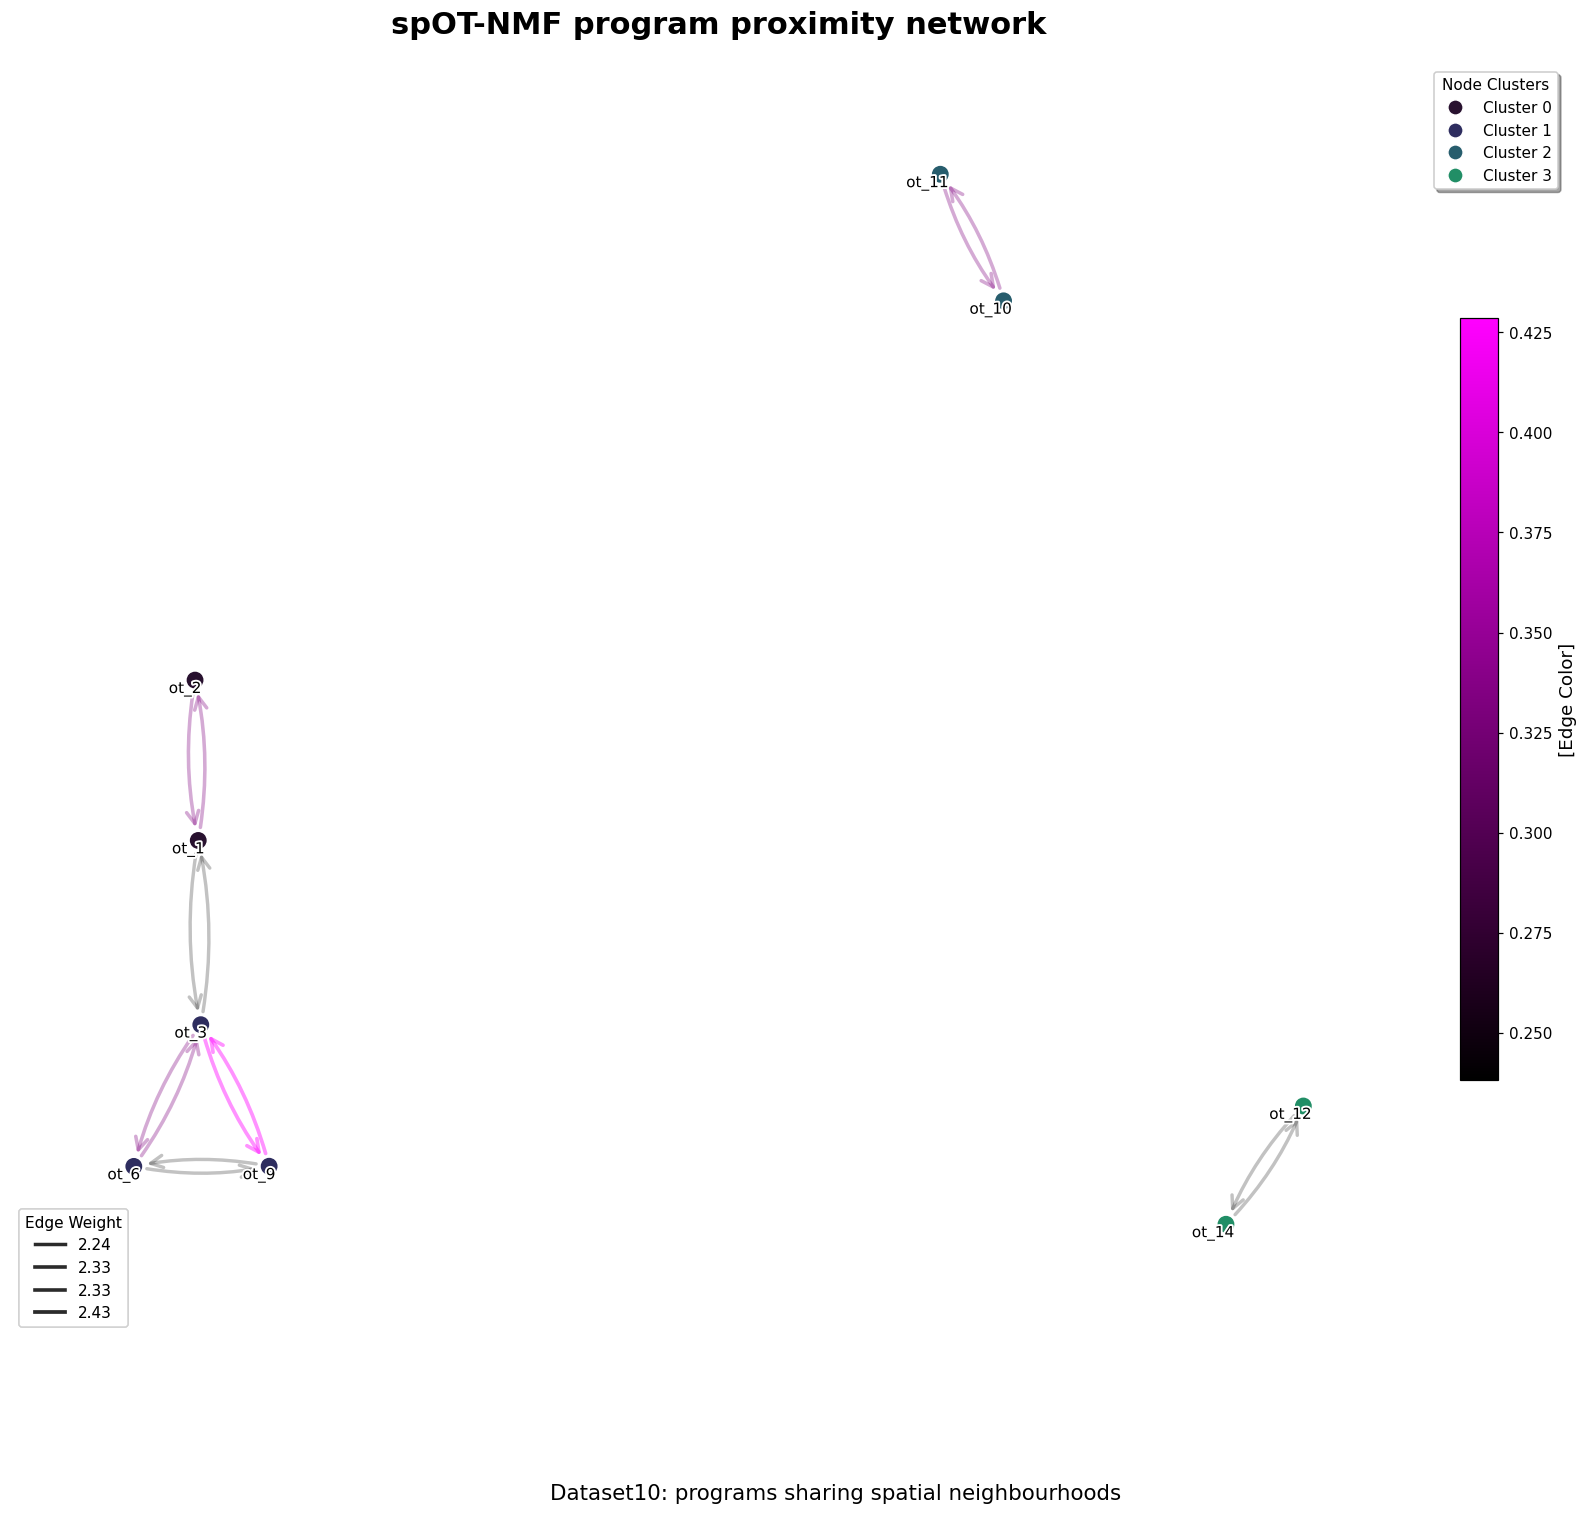

In [7]:
graph_filtered = nn.detect_communities_infomap(graph_filtered)
niches = sorted({graph_filtered.nodes[n]["cluster"] for n in graph_filtered.nodes})
print(f"Infomap found {len(niches)} niche(s): {niches}")

pos = nn.get_node_positions(graph_filtered, layout_algorithm="graphopt")
fig, ax = nn.base_plot(
    graph_filtered, pos,
    title="spOT-NMF program proximity network",
    suptitle=f"{SAMPLE_NAME}: programs sharing spatial neighbourhoods",
)
plt.show()

## 6. In-niche vs. cross-niche connections

`calculate_outgoing_and_incoming_connections` tallies, for each program, how many
edges stay **within** its own niche versus reach **out** to each other niche.
`plot_connection_heatmap` visualises this as a clustered heatmap — a compact
summary of which niches are self-contained and which are cross-talking.

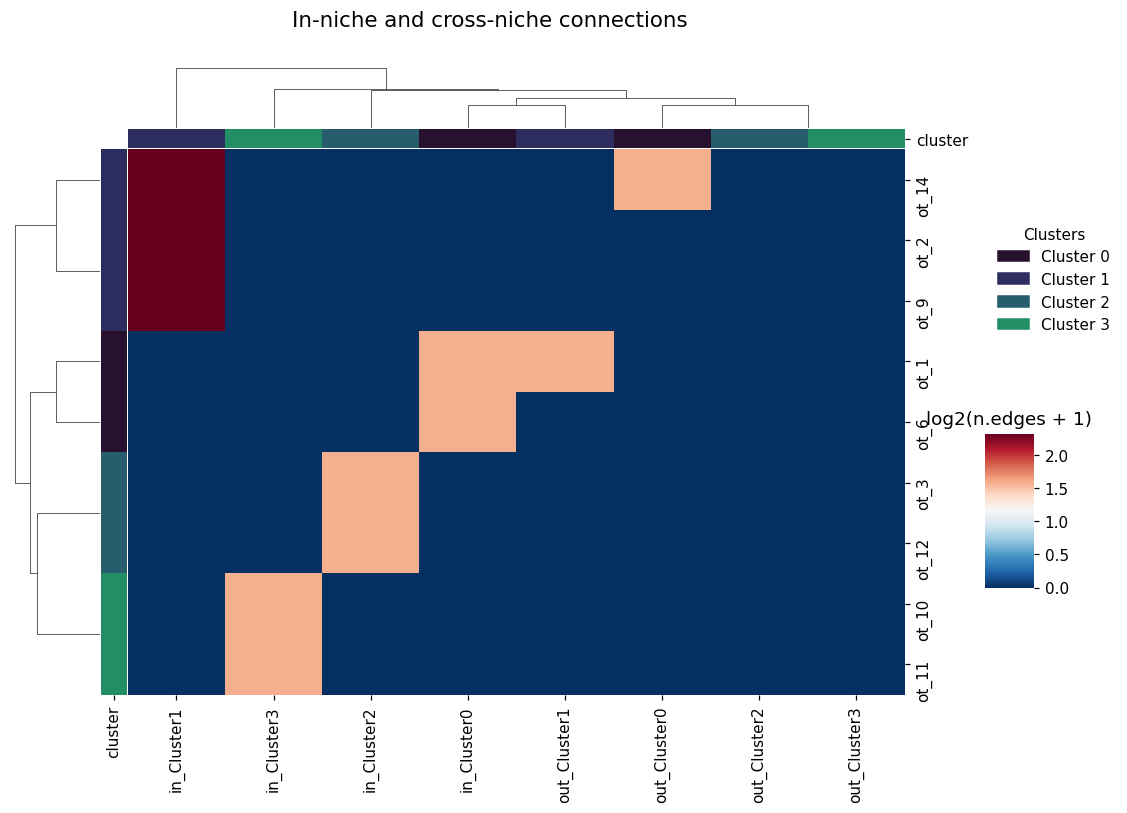

In [8]:
group_connections, columnannot, rowannot = nn.calculate_outgoing_and_incoming_connections(graph_filtered)
group_connections = np.log2(group_connections + 1)

fig, ax = nn.plot_connection_heatmap(
    group_connections, rowannot=rowannot, columnannot=columnannot,
    figsize=(9, 7), cmap="RdBu_r",
    suptitle="In-niche and cross-niche connections",
    legend_title="log2(n.edges + 1)",
)
plt.show()

## 7. The one-call API (and CLI)

Everything above is wrapped by `niche_networks.plot_network_analysis`, which reads
`topics_per_spot_<sample>.csv` from `results_dir/<sample>/`, runs the whole
pipeline, and writes the network + heatmap PDFs to disk. We first save our usages
where it expects them, then call it.

In [9]:
results_dir = Path("results")
sample_dir = results_dir / SAMPLE_NAME
sample_dir.mkdir(parents=True, exist_ok=True)
W.to_csv(sample_dir / f"topics_per_spot_{SAMPLE_NAME}.csv")

nn.plot_network_analysis(
    results_dir=str(results_dir),
    sample_name=SAMPLE_NAME,
    usage_threshold=USAGE_THRESHOLD,   # 0
    n_bins=N_BINS,                     # 5
    edge_threshold=EDGE_THRESHOLD,     # 0.2
    annot_file=None,                   # or a CSV with Program/Annotation columns
)

plt.close("all")   # the figures are written to PDF; don't also echo them inline here

print("\nGenerated files:")
for p in sorted(sample_dir.rglob("*")):
    if p.is_file():
        print("  ", p.relative_to(sample_dir))

Stats DataFrame created and saved.
Network graph built.


Network analysis plots saved.


Network connections heatmap saved.

Generated files:
   Dataset10_inside_outside_connection_heatmap.pdf
   samples_split\usagethresh0_Dataset10_filtered_nbins5_Dataset10_Program_Program_Interaction_Network_Edge_Cutoff.pdf
   samples_split\usagethresh0_Dataset10_nbins5_Dataset10_Program_Program_Interaction_Network_Edge_Cutoff.pdf
   topics_per_spot_Dataset10.csv
   uthresh0_None_Cell_Cell_Interaction_Enrichment.tsv


The equivalent command line (identical thresholds) is:

```bash
spotnmf network \
  --sample_name Dataset10 \
  --results_dir ./results \
  --usage_threshold 0 \
  --n_bins 5 \
  --edge_threshold 0.2
```

Pass `--annot_file annotations.csv` (a CSV with `Program` and `Annotation`
columns) to relabel the nodes with biological names instead of `ot_1`, `ot_2`, ….

## Choosing the thresholds

| Parameter | Meaning | Small section (this demo) | Large / multi-sample atlas (defaults) |
| --- | --- | --- | --- |
| `usage_threshold` | usage above which a program counts as *present* (after the 90th-pct step this is `0`) | `0` | `0` |
| `n_bins` | minimum co-occurrence observations required per edge | `5` | `1000` |
| `edge_threshold` | minimum \|conditional-presence probability\| to keep an edge | `0.2` | `0.199` |

If you get **"No edges meet the thresholds …"**, your `n_bins` is larger than the
number of present spots per program — lower `n_bins` (and/or `edge_threshold`).

## Summary

* Proximity networks turn a usage matrix into a **program co-occurrence graph** and
  cluster it into **niches** with Infomap.
* Building blocks: `compute_pairwise_stats` → `build_network_graph` →
  `detect_communities_infomap` → `base_plot`, plus the
  `calculate_outgoing_and_incoming_connections` / `plot_connection_heatmap` summary.
* `plot_network_analysis` (or `spotnmf network`) runs the whole thing and saves PDFs.

**Next:** annotate the programs (see the [full pipeline tutorial](full_pipeline.ipynb))
and pass the resulting table via `annot_file` to get biologically labelled niches.